<a href="https://colab.research.google.com/github/jorgecedraz/PPEC0039---ESTATISTICA/blob/main/ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
categories:
- PPEC
- Ensino
- Estatística
date: 10 -07 -2026
description: Aula 7 - Notebook sobre Análise de Variância-ANOVA
image: Analise_de_variancia.png
title: "Análise de Variância"
---

# **ANÁLISE DE VARIÂNCIA (ANOVA)**

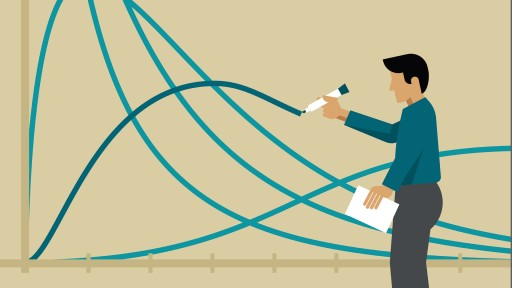

É um método para testar a igualdade de três ou mais médias populacionais, baseado na análise das variâncias amostrais. Os dados amostrais são separados em grupos segundo uma característica (fator). Fator (ou tratamento): é uma característica que permite distinguir diferentes populações umas das outras. Cada fator contém dois ou mais grupos (classificações).

Para minha pesquisa foi testado se o Fator (a adição de cinza de biomassa em 0%, 5%, 10% e 15%) afetava o resultado da Variável (a resistência à compressão do CSAB). O algoritmo pegou a variação de resistência entre os diferentes teores de cinza e a dividiu pela pequena variação que ocorreu dentro dos 5 corpos de prova de um mesmo teor. Como a mudança provocada pela cinza foi muito maior do que a simples oscilação normal de rompimento na prensa, o resultado matemático (o teste F da tabela) confirmou sem margem de erro que a substituição por resíduo altera, de fato, o desempenho mecânico do clínquer.

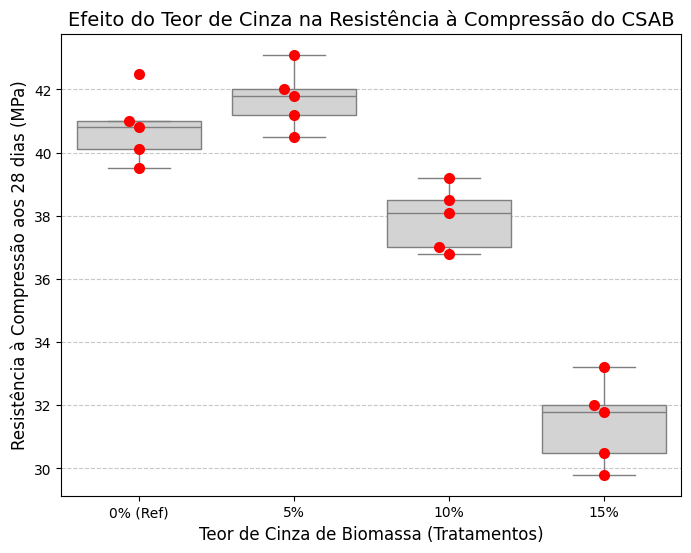

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# 1. Fator: Teor de Cinza de Biomassa
# Variável de Resposta: Resistência à Compressão aos 28 dias (MPa)
data = {
    '0% (Ref)': [40.1, 42.5, 41.0, 39.5, 40.8],
    '5%': [41.2, 43.1, 42.0, 40.5, 41.8],
    '10%': [38.5, 37.0, 39.2, 36.8, 38.1],
    '15%': [32.0, 30.5, 31.8, 33.2, 29.8]
}

# DataFrame
df = pd.DataFrame(data)

df_melted = df.melt(var_name='Teor_Cinza', value_name='Resistencia_MPa')

# 2. PROGRAMAÇÃO DO GRÁFICO (BOXPLOT + PONTOS DE DISPERSÃO)


plt.figure(figsize=(8, 6))

# Boxplot
sns.boxplot(x='Teor_Cinza', y='Resistencia_MPa', data=df_melted, color='lightgray')

sns.swarmplot(x='Teor_Cinza', y='Resistencia_MPa', data=df_melted, color='red', size=8)

# Configurações de título e eixos
plt.title('Efeito do Teor de Cinza na Resistência à Compressão do CSAB', fontsize=14)
plt.xlabel('Teor de Cinza de Biomassa (Tratamentos)', fontsize=12)
plt.ylabel('Resistência à Compressão aos 28 dias (MPa)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibição do gráfico
plt.show()

In [2]:
# 3. CÁLCULO DA TABELA ANOVA

modelo = ols('Resistencia_MPa ~ C(Teor_Cinza)', data=df_melted).fit()

tabela_anova = sm.stats.anova_lm(modelo, typ=2)

tabela_anova.columns = ['Soma dos Quadrados (SQ)', 'Graus de Liberdade (gl)', 'Razão F', 'Valor-p (Prob > F)']
tabela_anova.index = ['Entre Grupos (Teor_Cinza)', 'Dentro dos Grupos (Resíduo)']

print("\n--- TABELA ANOVA ---")
print(tabela_anova)


--- TABELA ANOVA ---
                             Soma dos Quadrados (SQ)  Graus de Liberdade (gl)  \
Entre Grupos (Teor_Cinza)                    321.706                      3.0   
Dentro dos Grupos (Resíduo)                   20.076                     16.0   

                               Razão F  Valor-p (Prob > F)  
Entre Grupos (Teor_Cinza)    85.463505        4.606011e-10  
Dentro dos Grupos (Resíduo)        NaN                 NaN  


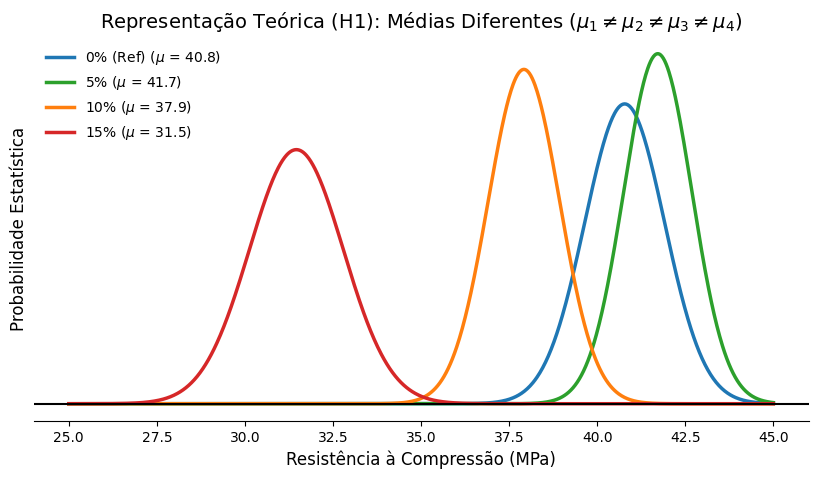

In [3]:
# 4. CURVAS NORMAIS TEÓRICAS

plt.figure(figsize=(10, 5))
eixo_x = np.linspace(25, 45, 1000)

# Cores para cada curva teórica
cores = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# Desenhando o Sino de Gauss para cada grupo do experimento
for coluna, cor in zip(df.columns, cores):
    media = df[coluna].mean()
    desvio_padrao = df[coluna].std()

    # Função matemática da Distribuição Normal
    curva_teorica = stats.norm.pdf(eixo_x, media, desvio_padrao)
    plt.plot(eixo_x, curva_teorica, color=cor, linewidth=2.5, label=fr'{coluna} ($\mu$ = {media:.1f})')

plt.axhline(0, color='black', linewidth=1.5)
plt.title(r'Representação Teórica (H1): Médias Diferentes ($\mu_1 \neq \mu_2 \neq \mu_3 \neq \mu_4$)', fontsize=14)
plt.xlabel('Resistência à Compressão (MPa)', fontsize=12)
plt.ylabel('Probabilidade Estatística', fontsize=12)

# Limpando o gráfico
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.legend(frameon=False)
plt.show()